# Notebook 1 — Exploratory Data Analysis

Before building any model, we need to understand what we're working with. This notebook explores the song dataset through univariate, bivariate, and multivariate analysis to identify patterns and inform our preprocessing decisions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# consistent plot style
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('../data/train.csv')
print('Shape:', df.shape)
df.head()

Shape: (28362, 24)


,Unnamed: 0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world/life,...,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,topic,age
0,0,mukesh,mohabbat bhi jhoothi,1950,pop,hold time feel break feel untrue convince spea...,95,0.000598,0.063746,0.000598,...,0.263751,0.000598,0.039288,0.000598,0.000598,0.000598,0.380299,0.117175,sadness,1.0
1,4,frankie laine,i believe,1950,pop,believe drop rain fall grow believe darkest ni...,51,0.035537,0.096777,0.443435,...,0.001284,0.001284,0.118034,0.001284,0.212681,0.051124,0.001284,0.001284,world/life,1.0
2,6,johnnie ray,cry,1950,pop,sweetheart send letter goodbye secret feel bet...,24,0.002770,0.002770,0.002770,...,0.250668,0.002770,0.323794,0.002770,0.002770,0.002770,0.002770,0.225422,music,1.0
3,10,pérez prado,patricia,1950,pop,kiss lips want stroll charm mambo chacha merin...,54,0.048249,0.001548,0.001548,...,0.001548,0.001548,0.001548,0.129250,0.001548,0.001548,0.225889,0.001548,romantic,1.0
4,12,giorgos papadopoulos,apopse eida oneiro,1950,pop,till darling till matter know till dream live ...,48,0.001350,0.001350,0.417772,...,0.001350,0.001350,0.001350,0.001350,0.001350,0.029755,0.068800,0.001350,romantic,1.0


In [2]:
# Basic overview — datatypes, nulls
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28362 entries, 0 to 28361
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                28362 non-null  int64  
 1   artist_name               28362 non-null  object 
 2   track_name                28362 non-null  object 
 3   release_date              28362 non-null  int64  
 4   genre                     28362 non-null  object 
 5   lyrics                    28362 non-null  object 
 6   len                       28362 non-null  int64  
 7   dating                    28362 non-null  float64
 8   violence                  28362 non-null  float64
 9   world/life                28362 non-null  float64
 10  night/time                28362 non-null  float64
 11  shake the audience        28362 non-null  float64
 12  family/gospel             28362 non-null  float64
 13  romantic                  28362 non-null  float64
 14  commun

In [3]:
# Summary stats on numeric columns
numeric_cols = ['dating','violence','world/life','night/time','shake the audience',
                'family/gospel','romantic','communication','obscene','music',
                'movement/places','light/visual perceptions','family/spiritual',
                'sadness','feelings','age','len']

df[numeric_cols].describe().round(3)

,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,communication,obscene,music,movement/places,light/visual perceptions,family/spiritual,sadness,feelings,age,len
count,28362.000,28362.000,28362.000,28362.000,28362.000,28362.000,28362.000,28362.000,28362.000,28362.000,28362.000,28362.000,28362.000,28362.000,28362.000,28362.000,28362.000
mean,0.021,0.118,0.121,0.057,0.017,0.017,0.049,0.077,0.097,0.060,0.047,0.049,0.024,0.129,0.031,0.425,73.031
std,0.052,0.179,0.172,0.112,0.041,0.042,0.106,0.109,0.181,0.123,0.092,0.090,0.051,0.181,0.072,0.264,41.832
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.014,1.000
25%,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.186,42.000
50%,0.001,0.003,0.007,0.002,0.002,0.002,0.002,0.003,0.002,0.002,0.002,0.002,0.002,0.005,0.002,0.414,63.000
75%,0.004,0.193,0.198,0.066,0.010,0.005,0.042,0.132,0.089,0.055,0.054,0.064,0.026,0.235,0.033,0.643,93.000
max,0.648,0.982,0.962,0.974,0.497,0.545,0.941,0.646,0.992,0.957,0.638,0.668,0.618,0.981,0.959,1.000,199.000


## Univariate Analysis

First let's look at individual columns — distributions, genre counts, and score spreads.

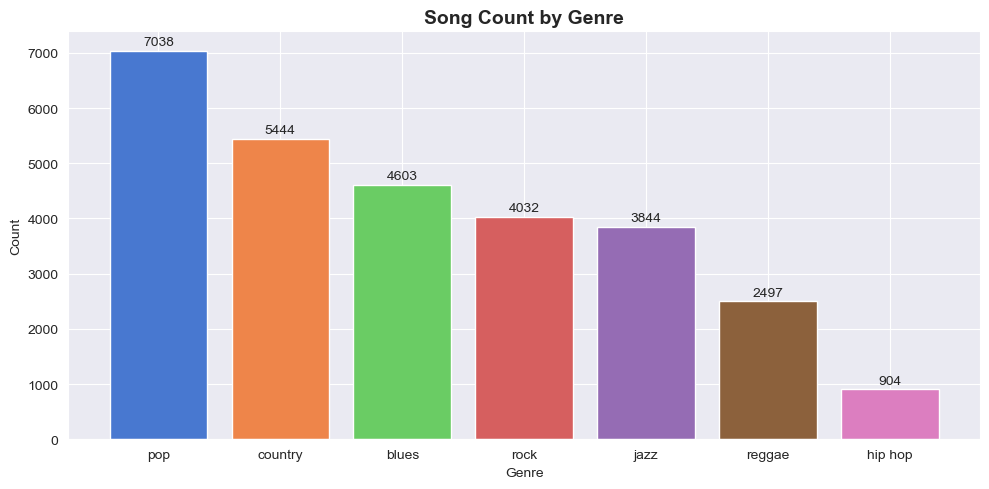

In [4]:
# Genre distribution
fig, ax = plt.subplots(figsize=(10, 5))
genre_counts = df['genre'].value_counts()
bars = ax.bar(genre_counts.index, genre_counts.values, color=sns.color_palette('muted', len(genre_counts)))
ax.set_title('Song Count by Genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Count')

# label each bar
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

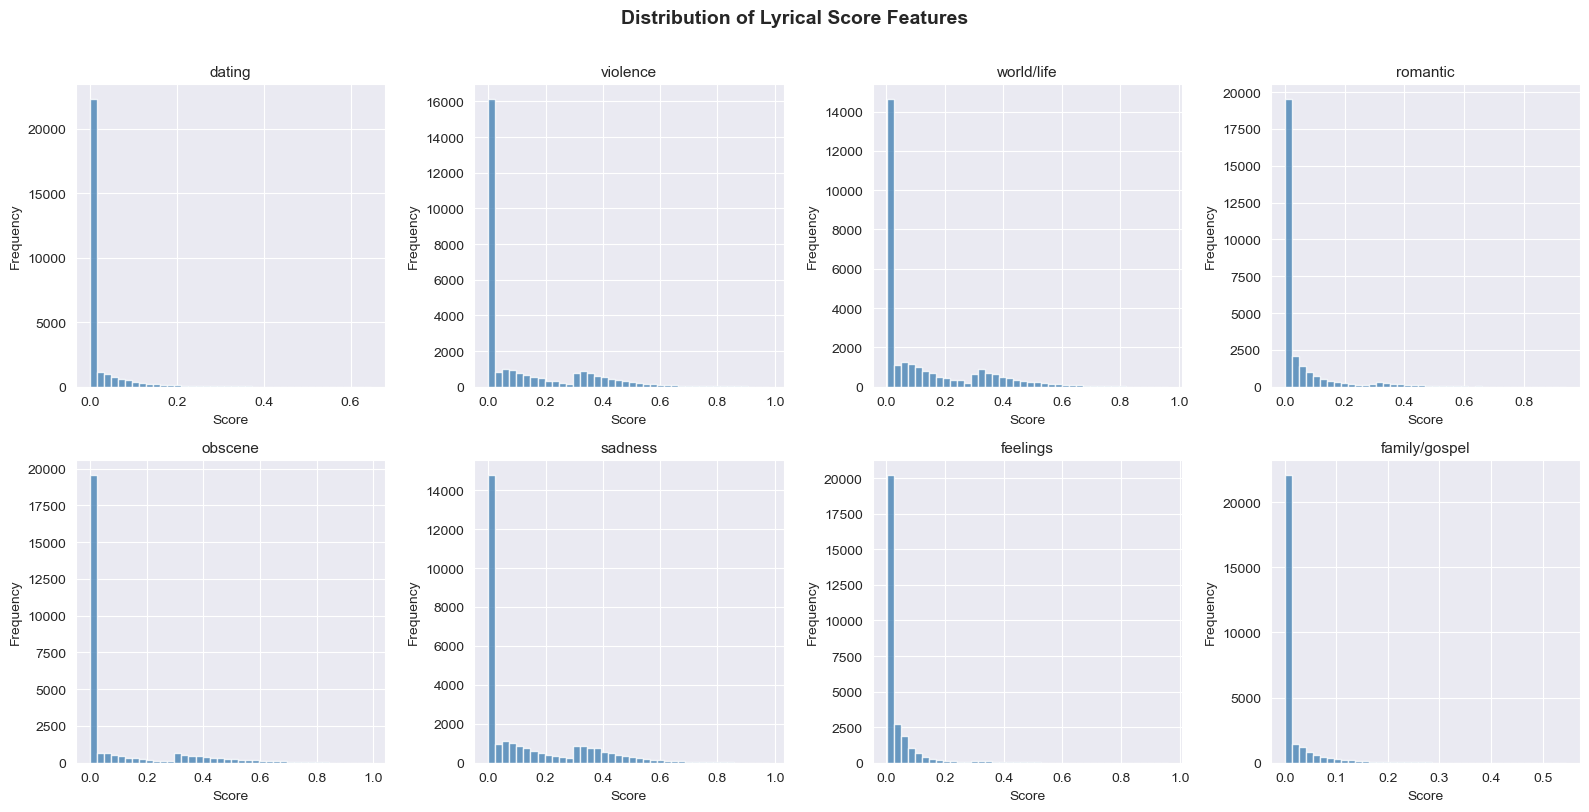

In [5]:
# Distribution of lyric score features
score_cols = ['dating','violence','world/life','romantic','obscene','sadness','feelings','family/gospel']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(score_cols):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Lyrical Score Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

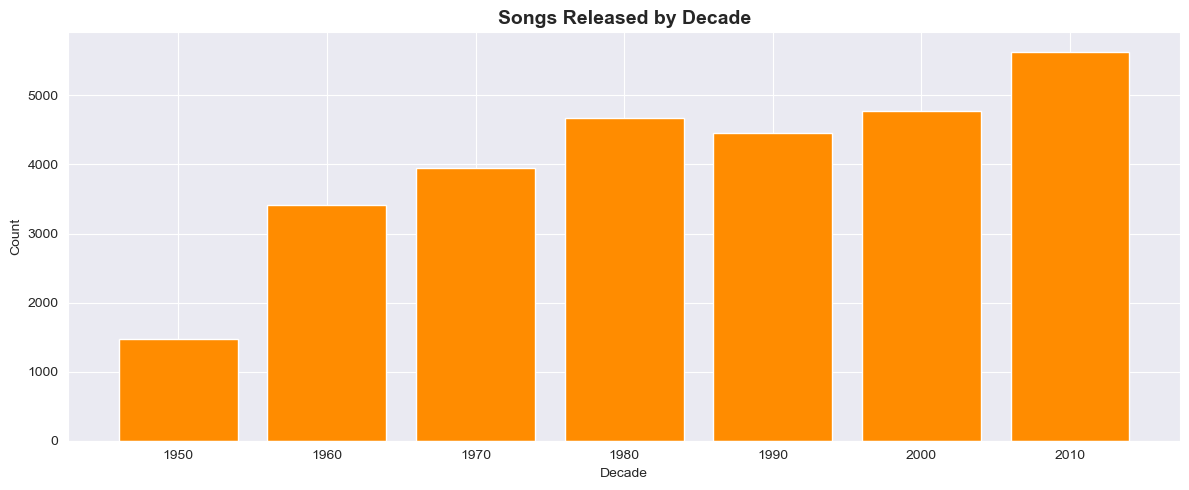

In [6]:
# How songs are distributed over time (release decade)
df['decade'] = (df['release_date'] // 10) * 10
decade_counts = df['decade'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(decade_counts.index.astype(str), decade_counts.values, color='darkorange', edgecolor='white')
ax.set_title('Songs Released by Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## Bivariate Analysis

Now let's look at how features relate to each other — particularly how lyrical themes vary across genres.

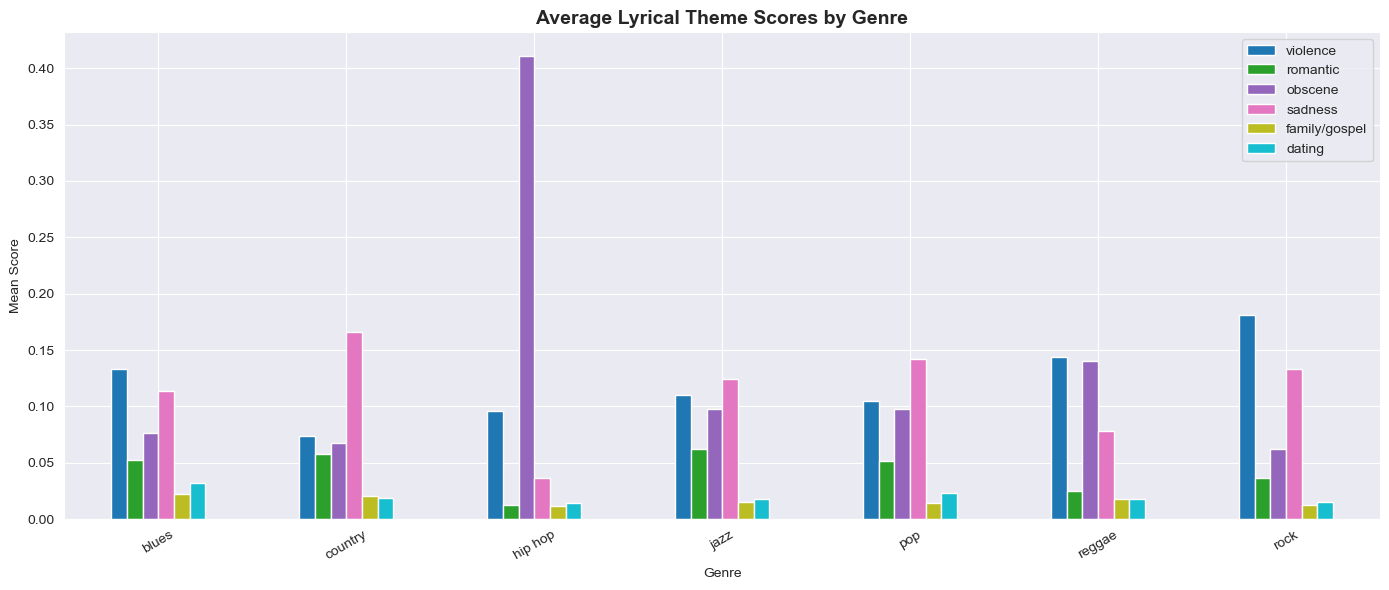

In [7]:
# Average lyrical scores broken down by genre
genre_means = df.groupby('genre')[['violence','romantic','obscene','sadness','family/gospel','dating']].mean()

genre_means.plot(kind='bar', figsize=(14, 6), colormap='tab10', edgecolor='white')
plt.title('Average Lyrical Theme Scores by Genre', fontsize=14, fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Mean Score')
plt.xticks(rotation=30)
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

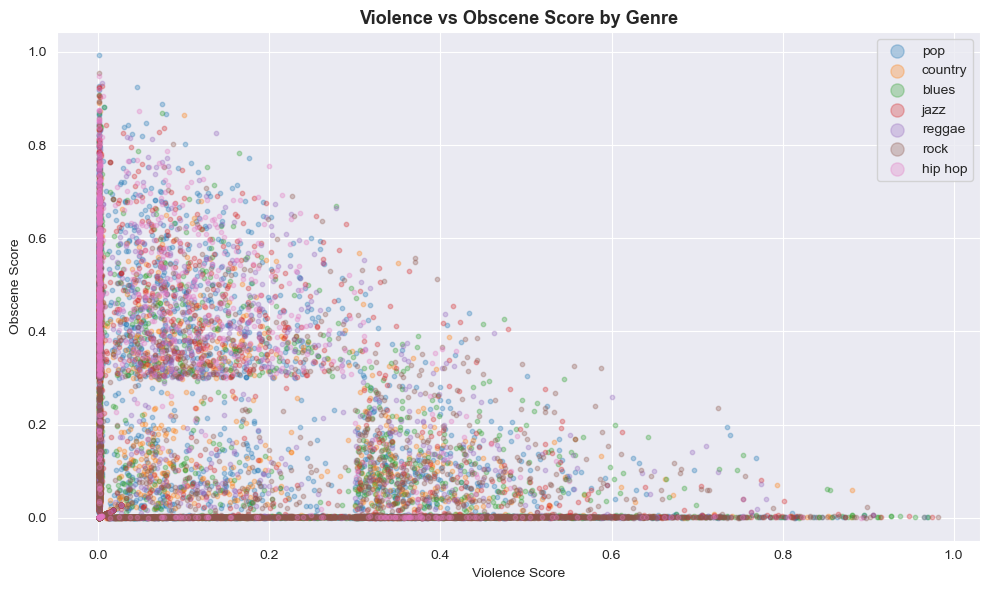

In [8]:
# Violence vs obscene scores — colored by genre
fig, ax = plt.subplots(figsize=(10, 6))
genres = df['genre'].unique()
palette = sns.color_palette('tab10', len(genres))

for i, genre in enumerate(genres):
    subset = df[df['genre'] == genre]
    ax.scatter(subset['violence'], subset['obscene'], alpha=0.3, s=10,
               color=palette[i], label=genre)

ax.set_title('Violence vs Obscene Score by Genre', fontsize=13, fontweight='bold')
ax.set_xlabel('Violence Score')
ax.set_ylabel('Obscene Score')
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

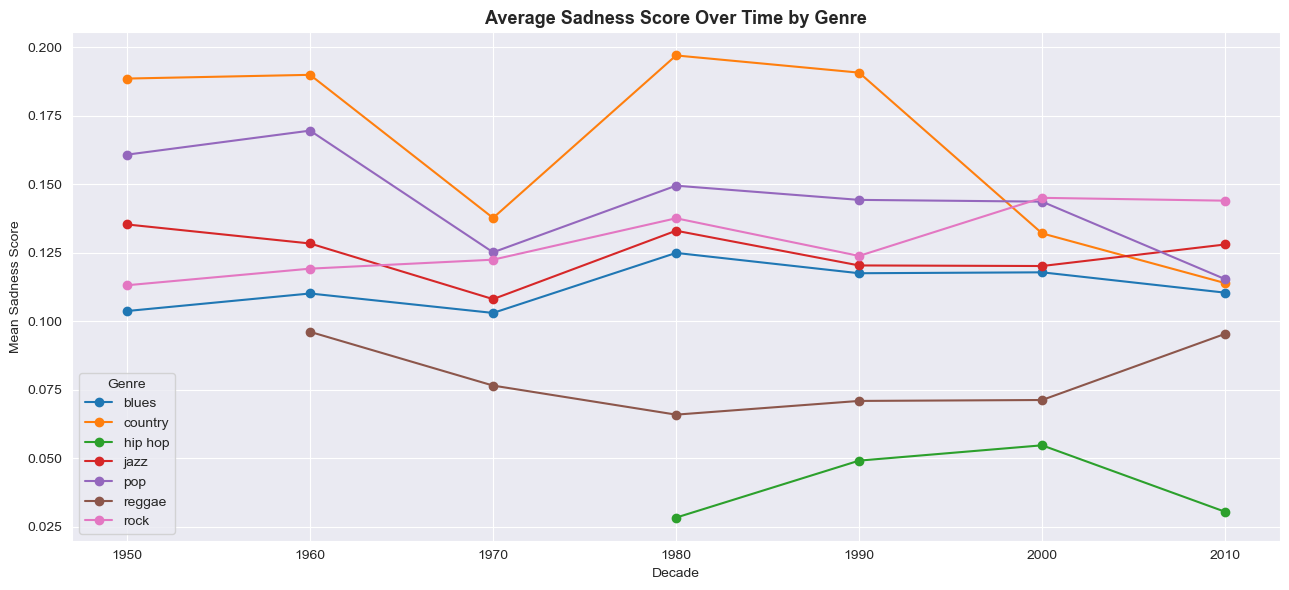

In [9]:
# How sadness scores shifted over time by genre
decade_genre = df.groupby(['decade','genre'])['sadness'].mean().unstack()

decade_genre.plot(figsize=(13, 6), marker='o')
plt.title('Average Sadness Score Over Time by Genre', fontsize=13, fontweight='bold')
plt.xlabel('Decade')
plt.ylabel('Mean Sadness Score')
plt.legend(title='Genre')
plt.tight_layout()
plt.show()

## Multivariate Analysis

Let's look at feature correlations across all numeric columns, and see how multiple features interact at once.

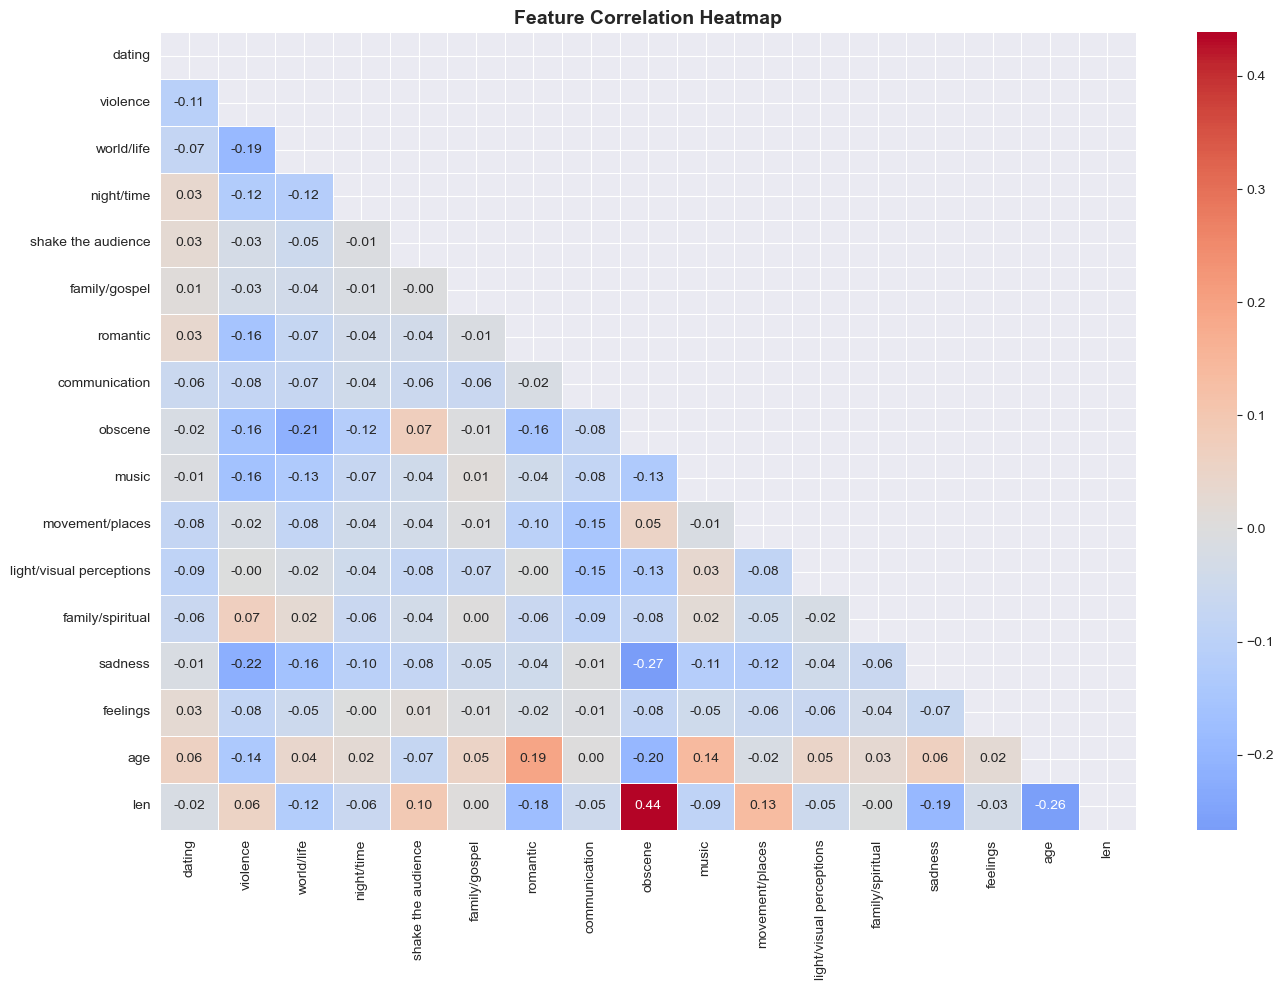

In [10]:
# Correlation heatmap of all numeric lyrical features
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/var/folders/hz/42ztdjs51cx58k_6ql8c6mqw0000gn/T/ipykernel_18750/981401633.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y='romantic', palette='pastel', ax=axes[0])
/var/folders/hz/42ztdjs51cx58k_6ql8c6mqw0000gn/T/ipykernel_18750/981401633.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y='violence', palette='pastel', ax=axes[1])


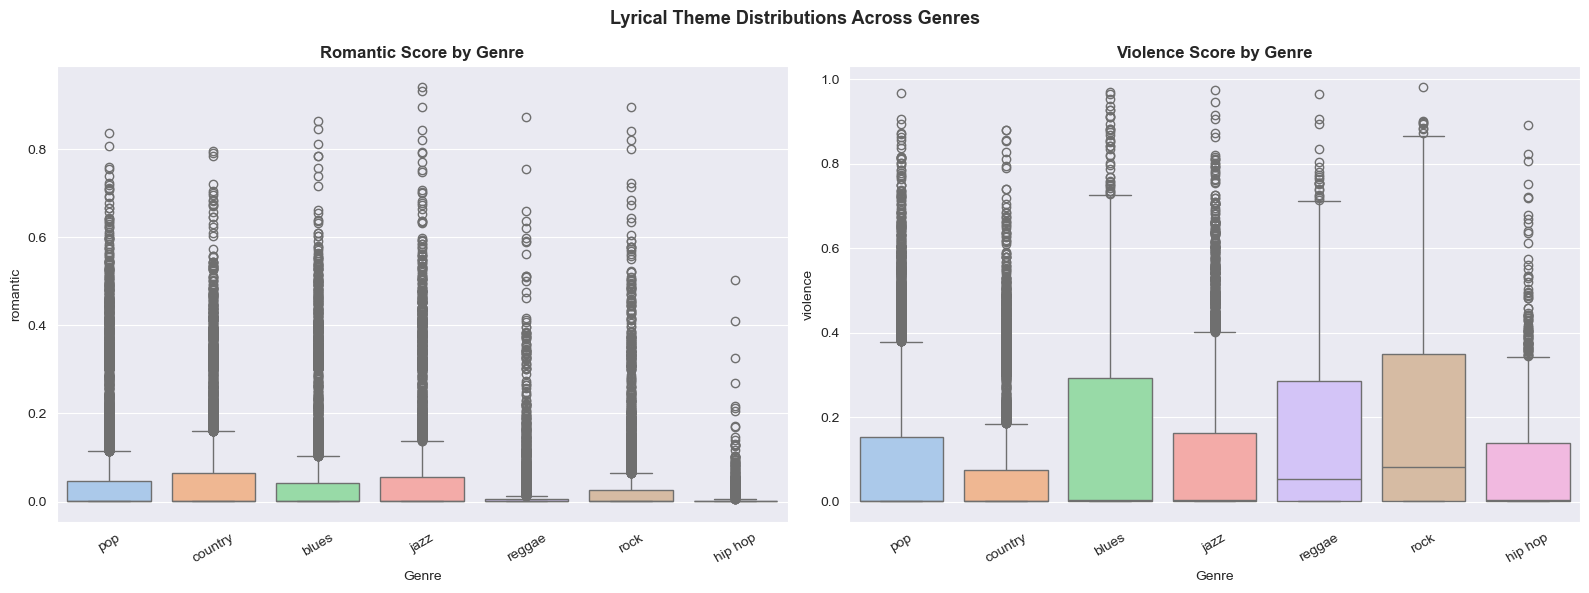

In [11]:
# Boxplots — romantic and violence scores across genres side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x='genre', y='romantic', palette='pastel', ax=axes[0])
axes[0].set_title('Romantic Score by Genre', fontweight='bold')
axes[0].set_xlabel('Genre')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='genre', y='violence', palette='pastel', ax=axes[1])
axes[1].set_title('Violence Score by Genre', fontweight='bold')
axes[1].set_xlabel('Genre')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Lyrical Theme Distributions Across Genres', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

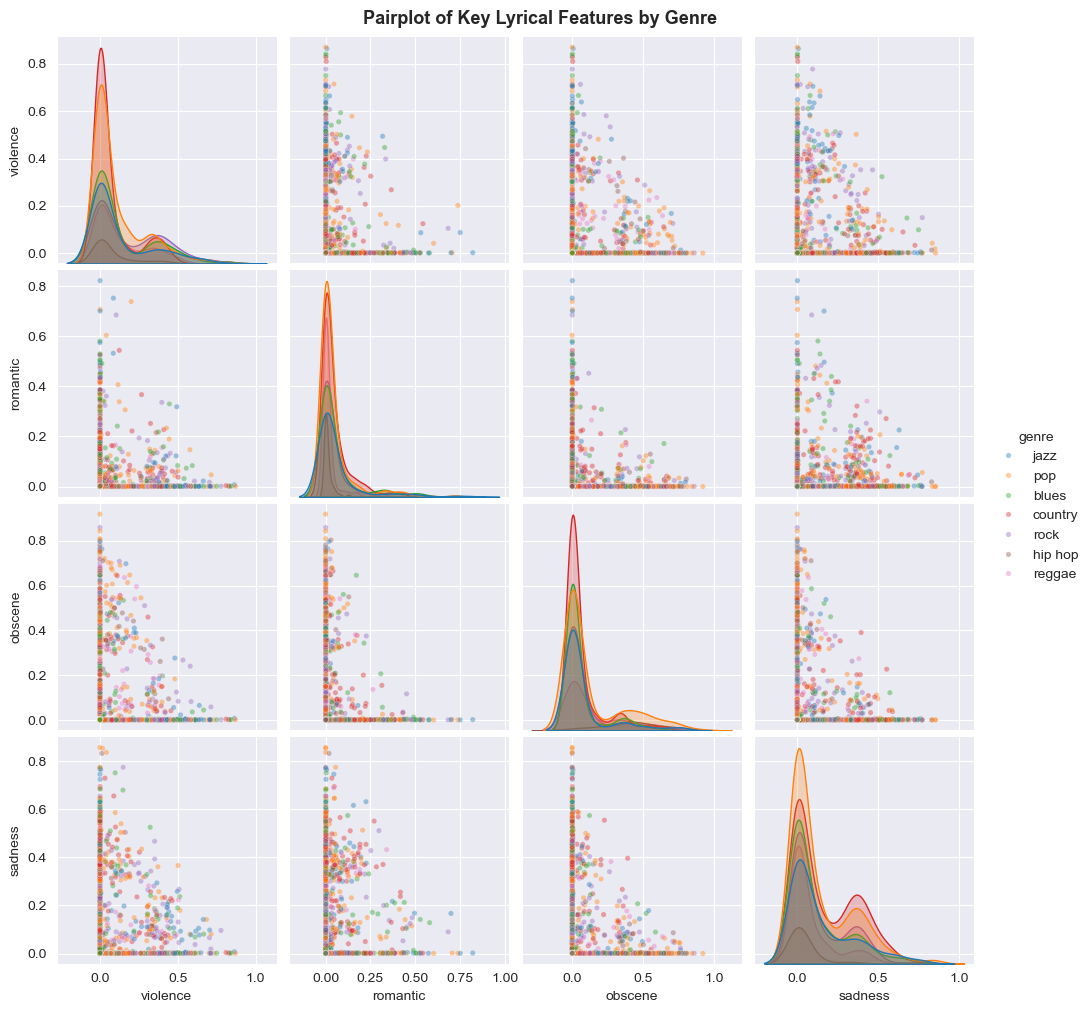

In [12]:
# Pairplot on a sample of key features — colored by genre
sample = df.sample(1500, random_state=42)
pair_cols = ['violence', 'romantic', 'obscene', 'sadness', 'genre']

sns.pairplot(sample[pair_cols], hue='genre', plot_kws={'alpha': 0.4, 's': 15},
             diag_kind='kde', palette='tab10')
plt.suptitle('Pairplot of Key Lyrical Features by Genre', y=1.01, fontsize=13, fontweight='bold')
plt.show()

## EDA Summary

Key takeaways from this analysis:

- **Genre distribution is uneven** — pop and country dominate, hip hop has the fewest songs.
- **Most lyrical score features are heavily right-skewed** — the majority of songs score near zero on most themes, with a small subset scoring high.
- **Hip hop shows noticeably higher obscene and violence scores** compared to other genres, while blues and country lean toward sadness and romantic themes.
- **No features show extremely high correlation (>0.7)** with one another, meaning we won't need to drop columns purely based on multicollinearity.
- **The `lyrics`, `artist_name`, `track_name`, and `Unnamed: 0` columns are non-numeric identifiers** — they need to be handled in preprocessing.
- **`topic` and `genre` are categorical** — we'll encode or drop them depending on model needs.